# 07 - Baseline Comparison: SA-PINN, RAR-PINN, gPINN vs AC-PINN
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

Benchmarks three published baseline methods against our AC-PINN, across
**all 4 PDEs** (Burgers, Heat, Wave, Allen-Cahn), each under the same
noisy sparse data condition used by the ablation study (N_ic=20, N_bc=20,
noise_eps=0.1; N_f=2000, except Allen-Cahn which uses N_f=3000 to match
notebooks 01-04).

| Model | Loss weighting | Collocation points |
|---|---|---|
| Vanilla PINN | fixed | fixed, uniform |
| SA-PINN (Wang et al. 2022) | learned via softmax + gradient ascent | fixed, uniform |
| RAR-PINN (Lu et al. 2021) | fixed | grows via residual-based addition |
| gPINN (Yu et al. 2022) | fixed | fixed, uniform (adds gradient-enhanced residual loss) |
| AC-PINN (both, tuned) | adaptive (gradient+ratio switching) | curriculum-sampled |

**Baseline 1 - SA-PINN (Self-Adaptive PINN, Wang et al. 2022).**
IC/BC/PDE loss weights are trainable parameters normalized by softmax.
The network *minimizes* the weighted loss while the weights are updated
by *gradient ascent* on that same loss (adversarial min-max), so terms
the network is fitting poorly get pushed to higher weight automatically.
Implemented as `SAWeightPINN` in `pinn_base.py`.

**Baseline 2 - RAR-PINN (Residual-based Adaptive Refinement, Lu et al. 2021).**
Loss weights are fixed like the vanilla PINN. Every `rar_update_every`
epochs the PDE residual is evaluated on a dense candidate grid and the
top-k highest-residual points are ADDED to the collocation set (points
are only appended, never replaced). Implemented as `RARPINNSolver` in
`pinn_base.py`.

**Baseline 3 - gPINN (Gradient-enhanced PINN, Yu et al. 2022).**
Fixed loss weights like the vanilla PINN, but the loss also penalizes
the spatial and temporal gradients of the PDE residual itself,
`||grad_x r||^2` and `||grad_t r||^2` (weight `lambda_g=0.1`), encouraging
the residual to be flat rather than just pointwise small. Implemented as
`GPINNSolver` in `pinn_base.py`.

**AC-PINN (both, tuned)** uses the tuned hyperparameters from
`notebooks/01_burgers.ipynb`: `stage_thresholds=[0.8, 0.4, 0.1]`,
`min_epochs_per_stage=1500`, `min_epochs_before_switch=4000`,
`switch_eval_every=2000`, and `adaptive_resample=True` with
`plateau_window=300`, `plateau_tol=1e-5`.


In [ ]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, SAWeightPINN, RARPINNSolver,
    GPINNSolver, ACPINNSolver, BurgersFDM, HeatFDM, WaveFDM, AllenCahnFDM,
    Benchmark, save_metrics, save_history
)

EPOCHS = 10000
RESULTS = '../results/'
FIGURES = '../figures/'
os.makedirs(FIGURES + 'comparison', exist_ok=True)

PDES = ['burgers', 'heat', 'wave', 'allen_cahn']
PDE_LABELS = {'burgers': 'Burgers', 'heat': 'Heat', 'wave': 'Wave', 'allen_cahn': 'Allen-Cahn'}

# Per-PDE architecture, physical params, FDM ground truth, and the
# noisy-sparse data condition -- matching notebooks 01_burgers.ipynb,
# 02_heat.ipynb, 03_wave.ipynb, 04_allen_cahn.ipynb exactly.
PDE_CONFIGS = {
    'burgers': dict(
        layers=[2, 64, 64, 64, 64, 64, 1],
        pde_params={'nu': 0.01 / np.pi},
        fdm_cls=BurgersFDM, fdm_kwargs=dict(nx=256, nt=2000, nu=0.01 / np.pi),
        data_kwargs=dict(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1),
        vanilla_kwargs=dict(),
        N_pool=20000,
    ),
    'heat': dict(
        layers=[2, 32, 32, 32, 1],
        pde_params={'alpha': 0.01},
        fdm_cls=HeatFDM, fdm_kwargs=dict(nx=256, nt=1000, alpha=0.01),
        data_kwargs=dict(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1),
        vanilla_kwargs=dict(),
        N_pool=20000,
    ),
    'wave': dict(
        layers=[2, 64, 64, 64, 64, 64, 1],
        pde_params={'c': 1.0},
        fdm_cls=WaveFDM, fdm_kwargs=dict(nx=256, nt=2000, c=1.0),
        data_kwargs=dict(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1),
        vanilla_kwargs=dict(),
        N_pool=20000,
    ),
    'allen_cahn': dict(
        layers=[2, 128, 128, 128, 128, 128, 1],
        pde_params={'epsilon': 0.01},
        fdm_cls=AllenCahnFDM, fdm_kwargs=dict(nx=256, nt=5000, epsilon=0.01),
        # Allen-Cahn's noisy-sparse condition uses N_f=3000, not 2000
        # (matches notebooks/04_allen_cahn.ipynb -- more collocation
        # points to cope with the stiff interface).
        data_kwargs=dict(N_ic=20, N_bc=20, N_f=3000, noise_eps=0.1),
        # Vanilla PINN uses a higher lambda_pde=10.0 on Allen-Cahn,
        # matching notebooks/04_allen_cahn.ipynb (only the vanilla
        # model -- the other baselines and AC-PINN keep the default).
        vanilla_kwargs=dict(lambda_pde=10.0),
        N_pool=30000,
    ),
}

# GEN_PARAMS: NoisyDataGenerator only accepts nu/alpha/c, NOT epsilon --
# Allen-Cahn's PDE_CONFIGS['allen_cahn']['pde_params'] carries 'epsilon'
# for the FDM/residual only, so it must be filtered out here.
GEN_PARAMS = {'nu', 'alpha', 'c'}

# AC-PINN uses plain defaults, weight_strategy='both' (matching
# notebooks 01-04) for consistency across all 4 PDEs.
ACPINN_INIT_KWARGS = dict(weight_strategy='both', ntk_init=True)
ACPINN_FIT_KWARGS = dict()

print(f'Device: {device}')


## Run all 4 PDEs: Vanilla, SA-PINN, RAR-PINN, gPINN, AC-PINN (both, tuned)


######################################################################
# PDE: Burgers
######################################################################


BurgersFDM solved in 0.5737s


D:\projects\AC-PINN\venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Baselines | Burgers | Vanilla | Epoch     0/10000] Total: 1.205343 | IC: 0.700619 | BC: 0.085829 | PDE: 0.083779


[Baselines | Burgers | Vanilla | Epoch  2000/10000] Total: 0.067978 | IC: 0.044208 | BC: 0.012990 | PDE: 0.002156


...

[Baselines | Burgers | AC-PINN (auto) | Epoch  2000/10000] Stage 1/4 | Total: 0.093481 | IC: 0.006449 | BC: 0.010916 | PDE: 0.001698 | lam=(5.10,5.30,1.63)


[Baselines | Burgers | AC-PINN (auto) | Epoch  4000/10000] Stage 2/4 | Total: 0.032430 | IC: 0.003689 | BC: 0.009284 | PDE: 0.000271 | lam=(2.52,2.32,5.80)


[Baselines | Burgers | AC-PINN (auto) | Epoch  6000/10000] Stage 3/4 | Total: 0.036111 | IC: 0.001399 | BC: 0.008576 | PDE: 0.001340 | lam=(10.00,2.24,2.15)


[Baselines | Burgers | AC-PINN (auto) | Epoch  8000/10000] Stage 4/4 | Total: 0.234384 | IC: 0.019217 | BC: 0.011427 | PDE: 0.097547 | lam=(0.45,0.27,2.28)



AC-PINN training complete in 196.51s

--- Burgers Baseline Benchmark Table (vs FDM ground truth) ---
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.207694   1.167011   0.069494   0.126312
  SA-PINN                     0.757951   1.935262   0.169931   0.460959
  RAR-PINN                    0.570917   1.856032   0.140191   0.347211
  gPINN                       0.427049   0.986864   0.141770   0.259716
  AC-PINN (auto)              0.273241   0.843720   0.097014   0.166176
Saved: ../results/burgers/baselines_metrics.npy
Saved: ../results/burgers/baselines_vanilla.npy
Saved: ../results/burgers/baselines_sapinn.npy
Saved: ../results/burgers/baselines_rarpinn.npy
Saved: ../results/burgers/baselines_gpinn.npy
Saved: ../results/burgers/baselines_acpinn_auto.npy


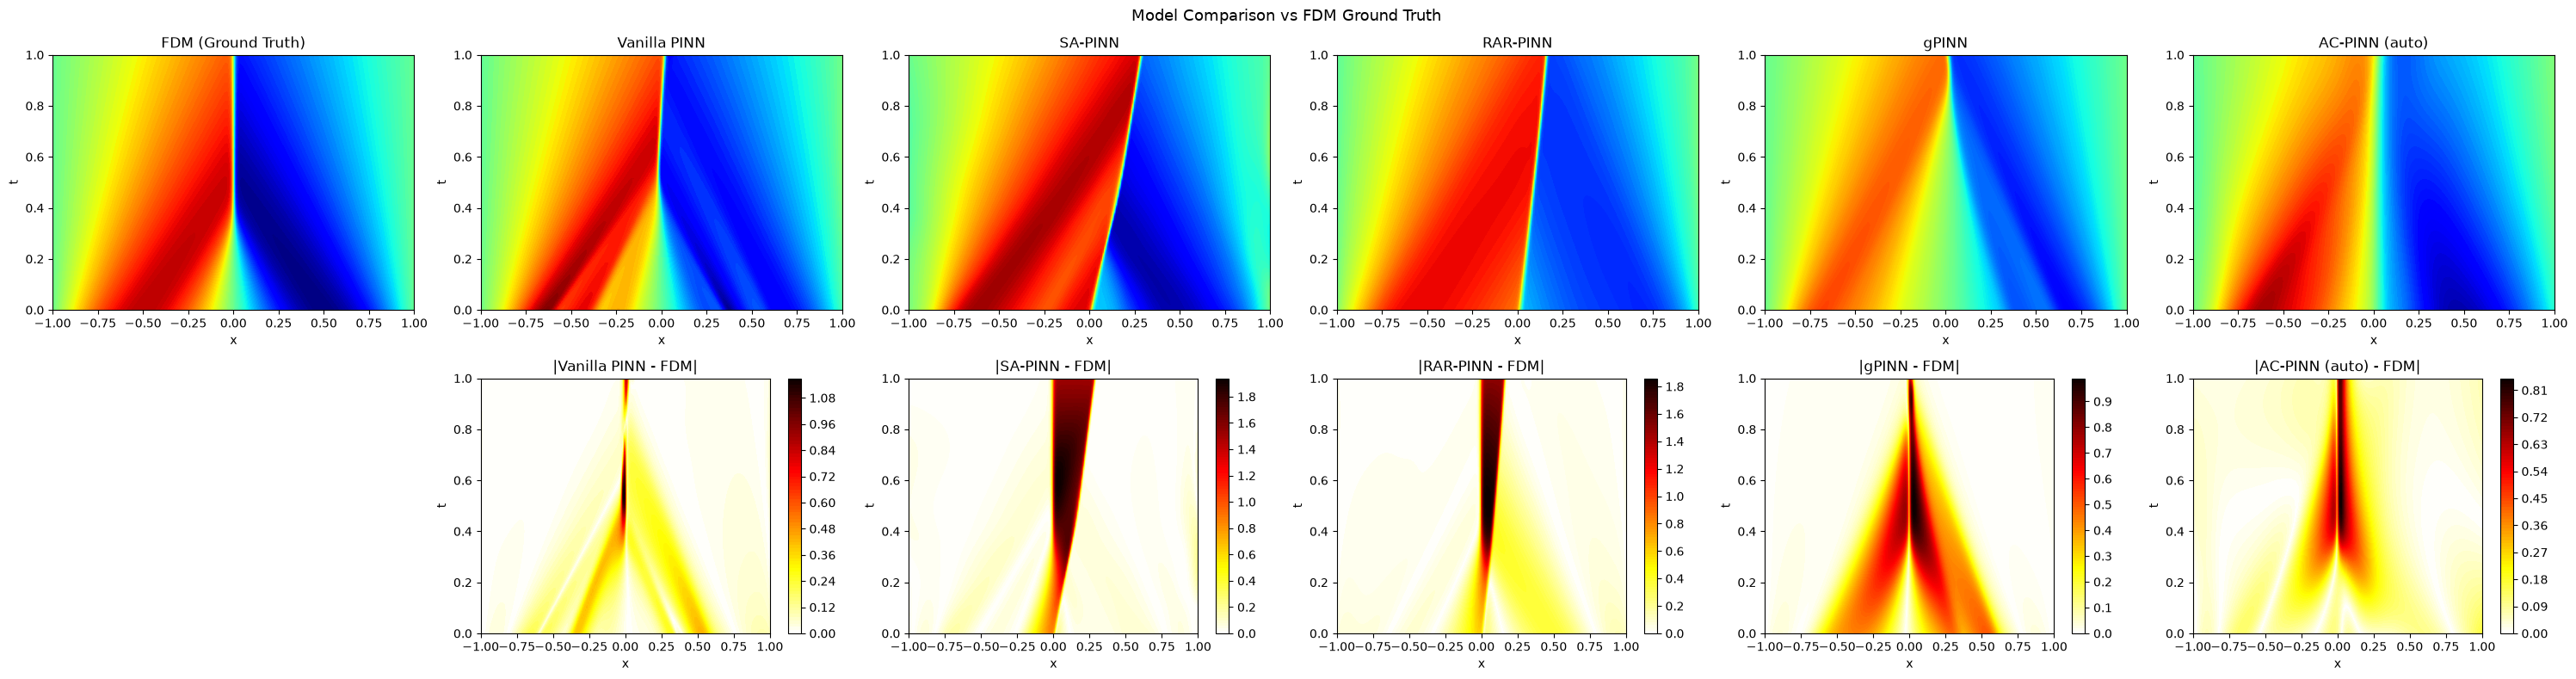

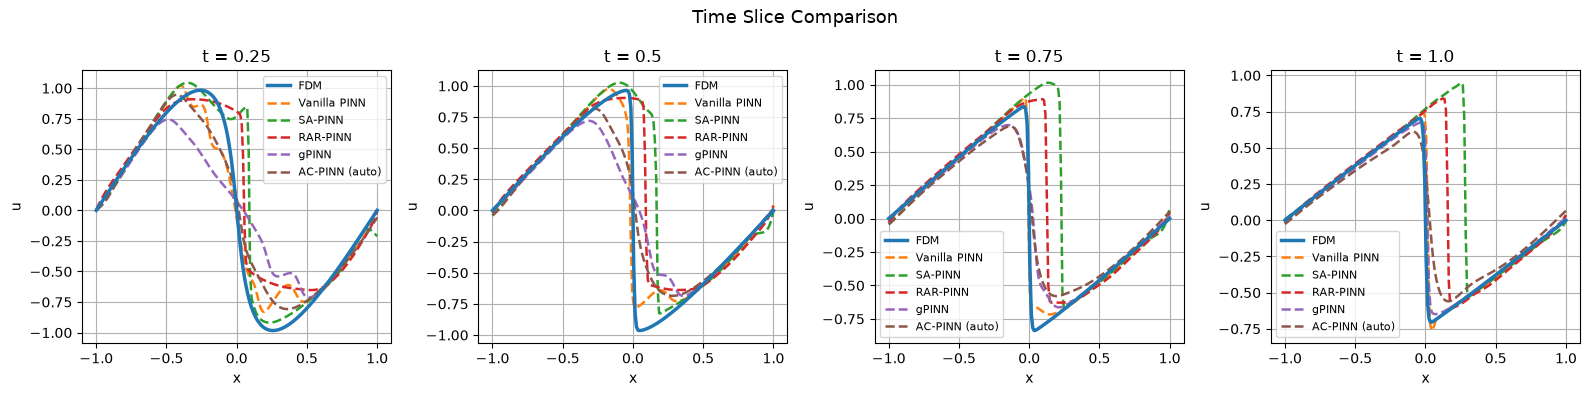

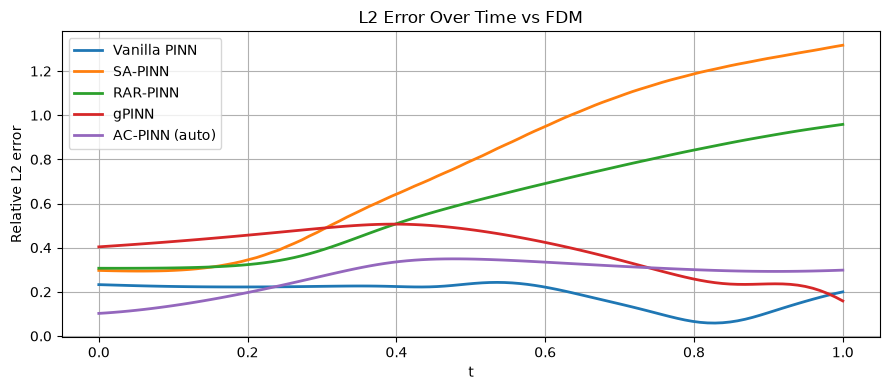


######################################################################
# PDE: Heat
######################################################################


HeatFDM solved in 0.2557s
[Baselines | Heat | Vanilla | Epoch     0/10000] Total: 0.546859 | IC: 0.512671 | BC: 0.028825 | PDE: 0.001073


[Baselines | Heat | Vanilla | Epoch  2000/10000] Total: 0.030152 | IC: 0.008833 | BC: 0.020289 | PDE: 0.000206


[Baselines | Heat | Vanilla | Epoch  4000/10000] Total: 0.028919 | IC: 0.008066 | BC: 0.019614 | PDE: 0.000248


[Baselines | Heat | Vanilla | Epoch  6000/10000] Total: 0.027588 | IC: 0.007045 | BC: 0.019021 | PDE: 0.000304


...

[Baselines | Heat | AC-PINN (auto) | Epoch  2000/10000] Stage 1/4 | Total: 0.081481 | IC: 0.008672 | BC: 0.015043 | PDE: 0.004298 | lam=(2.43,2.50,5.29)


[Baselines | Heat | AC-PINN (auto) | Epoch  4000/10000] Stage 2/4 | Total: 0.053593 | IC: 0.006253 | BC: 0.014923 | PDE: 0.000054 | lam=(5.46,1.27,10.00)


[Baselines | Heat | AC-PINN (auto) | Epoch  6000/10000] Stage 3/4 | Total: 0.081910 | IC: 0.005783 | BC: 0.016350 | PDE: 0.001268 | lam=(8.87,1.56,4.09)


[Baselines | Heat | AC-PINN (auto) | Epoch  8000/10000] Stage 4/4 | Total: 0.057554 | IC: 0.008969 | BC: 0.024046 | PDE: 0.001423 | lam=(0.78,2.09,0.12)



AC-PINN training complete in 137.95s

--- Heat Baseline Benchmark Table (vs FDM ground truth) ---
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.222775   0.523575   0.095454   0.149754
  SA-PINN                     0.087502   0.157403   0.052029   0.058821
  RAR-PINN                    0.146227   0.321790   0.069251   0.098297
  gPINN                       0.144131   0.316652   0.067746   0.096888
  AC-PINN (auto)              0.106412   0.161730   0.060087   0.071532
Saved: ../results/heat/baselines_metrics.npy
Saved: ../results/heat/baselines_vanilla.npy
Saved: ../results/heat/baselines_sapinn.npy
Saved: ../results/heat/baselines_rarpinn.npy
Saved: ../results/heat/baselines_gpinn.npy
Saved: ../results/heat/baselines_acpinn_auto.npy


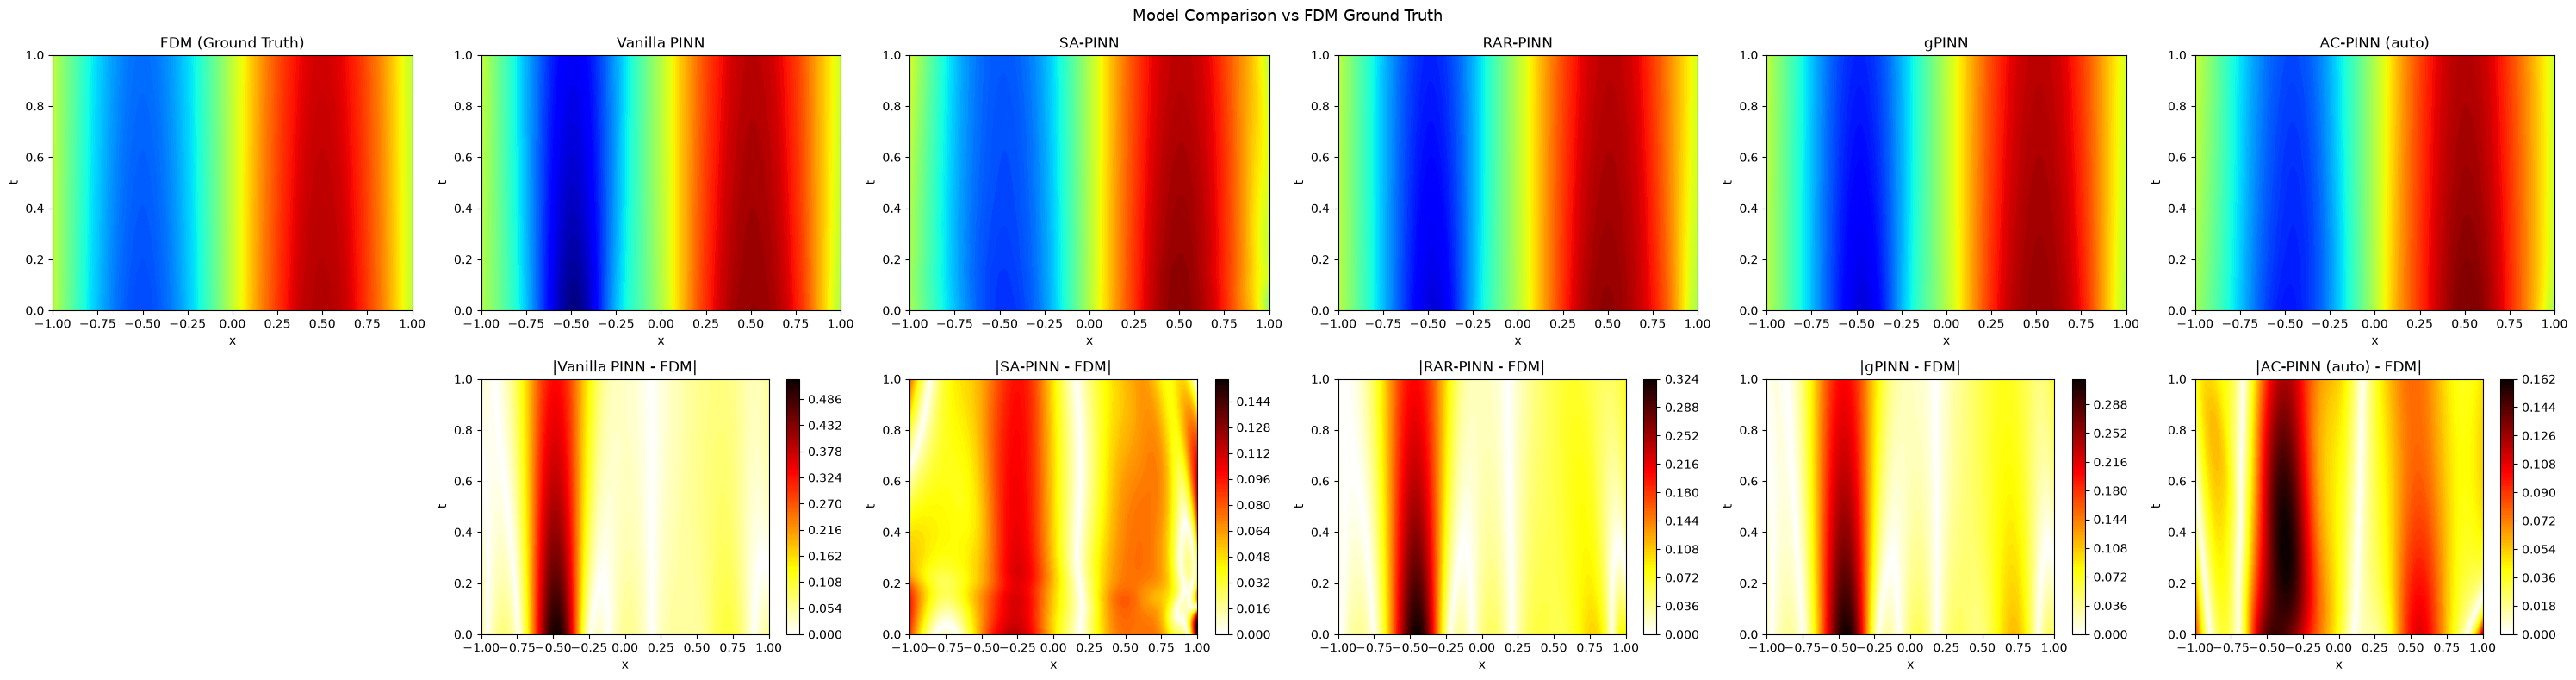

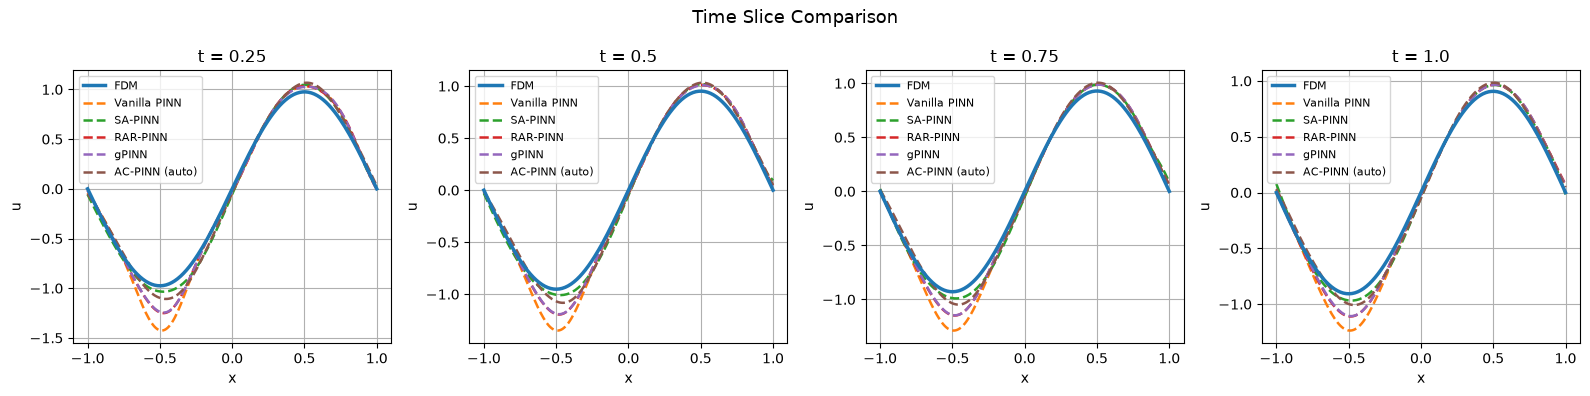

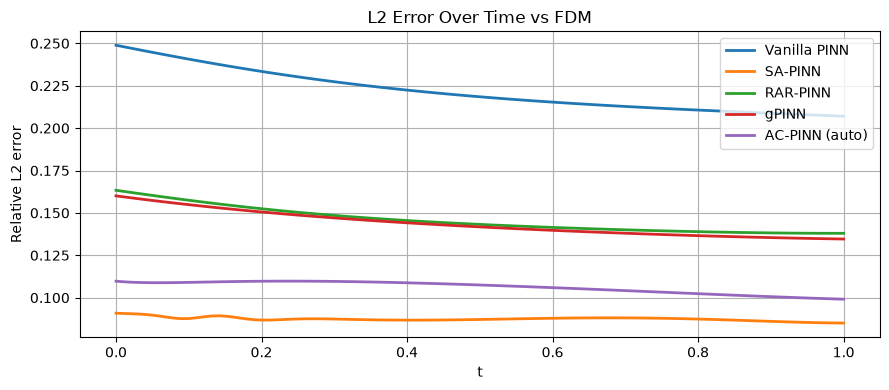


######################################################################
# PDE: Wave
######################################################################
WaveFDM solved in 0.0150s
[Baselines | Wave | Vanilla | Epoch     0/10000] Total: 0.861750 | IC: 0.474398 | BC: 0.276934 | PDE: 0.022084


[Baselines | Wave | Vanilla | Epoch  2000/10000] Total: 0.054607 | IC: 0.017736 | BC: 0.034680 | PDE: 0.000438


[Baselines | Wave | Vanilla | Epoch  4000/10000] Total: 0.028736 | IC: 0.010462 | BC: 0.017935 | PDE: 0.000068


[Baselines | Wave | Vanilla | Epoch  6000/10000] Total: 0.026119 | IC: 0.010145 | BC: 0.015592 | PDE: 0.000076


[Baselines | Wave | Vanilla | Epoch  8000/10000] Total: 0.024910 | IC: 0.010348 | BC: 0.014214 | PDE: 0.000069


...

[Baselines | Wave | AC-PINN (auto) | Epoch  2000/10000] Stage 1/4 | Total: 0.065921 | IC: 0.009895 | BC: 0.011610 | PDE: 0.001708 | lam=(3.35,1.79,7.03)


[Baselines | Wave | AC-PINN (auto) | Epoch  4000/10000] Stage 2/4 | Total: 0.076282 | IC: 0.027113 | BC: 0.029103 | PDE: 0.009720 | lam=(1.23,1.32,0.44)


[Baselines | Wave | AC-PINN (auto) | Epoch  6000/10000] Stage 3/4 | Total: 0.140359 | IC: 0.059397 | BC: 0.030108 | PDE: 0.006062 | lam=(1.86,0.95,0.19)


[Baselines | Wave | AC-PINN (auto) | Epoch  8000/10000] Stage 4/4 | Total: 0.072055 | IC: 0.021221 | BC: 0.030258 | PDE: 0.015854 | lam=(0.95,1.35,0.71)



AC-PINN training complete in 285.03s

--- Wave Baseline Benchmark Table (vs FDM ground truth) ---
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.069887   0.151845   0.029249   0.034854
  SA-PINN                     0.089539   0.264803   0.035913   0.044655
  RAR-PINN                    0.067733   0.142515   0.028298   0.033779
  gPINN                       0.067293   0.157255   0.027875   0.033560
  AC-PINN (auto)              0.157228   0.628738   0.055031   0.078412
Saved: ../results/wave/baselines_metrics.npy
Saved: ../results/wave/baselines_vanilla.npy
Saved: ../results/wave/baselines_sapinn.npy
Saved: ../results/wave/baselines_rarpinn.npy
Saved: ../results/wave/baselines_gpinn.npy
Saved: ../results/wave/baselines_acpinn_auto.npy


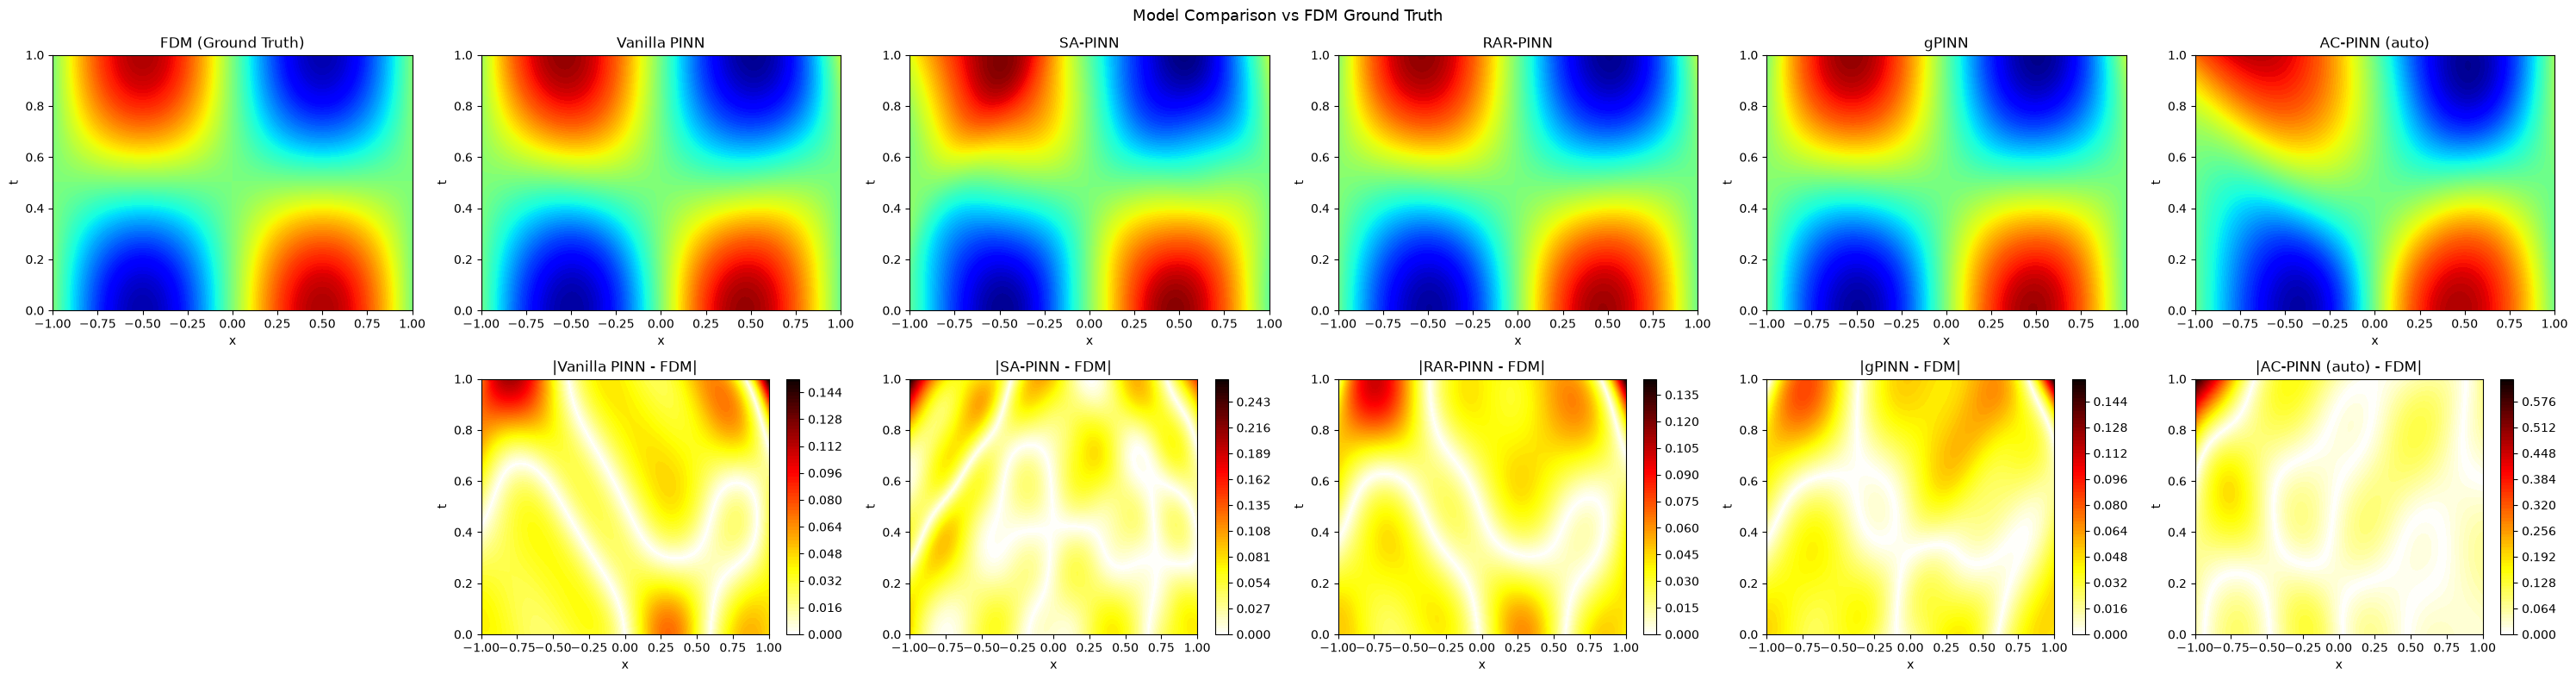

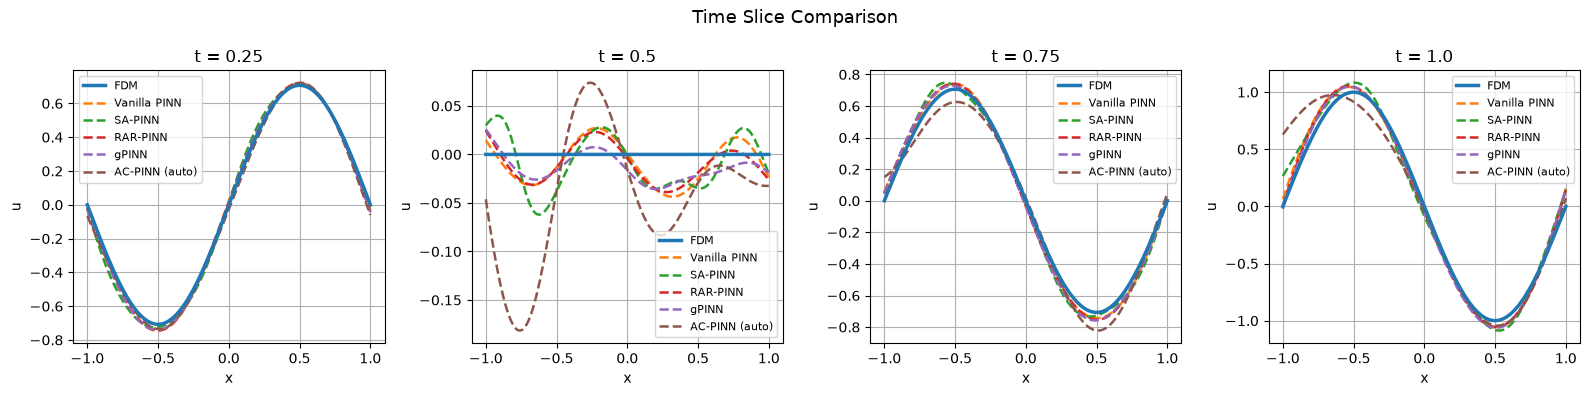

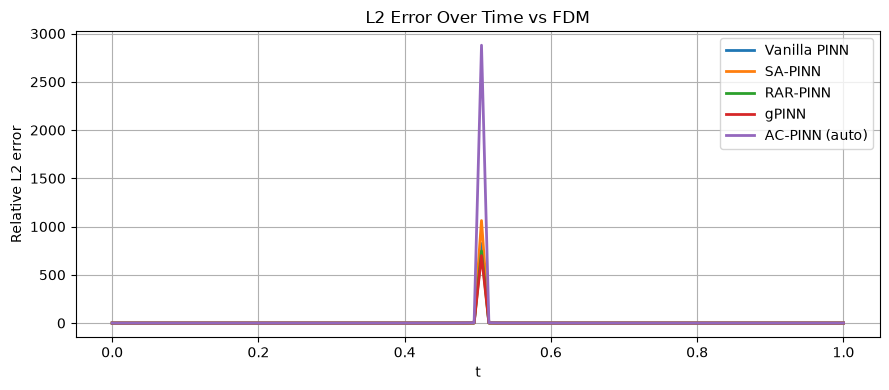


######################################################################
# PDE: Allen-Cahn
######################################################################


AllenCahnFDM solved in 1.5039s
[Baselines | Allen-Cahn | Vanilla | Epoch     0/10000] Total: 0.413835 | IC: 0.133256 | BC: 0.041337 | PDE: 0.023924


[Baselines | Allen-Cahn | Vanilla | Epoch  2000/10000] Total: 0.128135 | IC: 0.109558 | BC: 0.016175 | PDE: 0.000240


[Baselines | Allen-Cahn | Vanilla | Epoch  4000/10000] Total: 0.020936 | IC: 0.006426 | BC: 0.011992 | PDE: 0.000252


[Baselines | Allen-Cahn | Vanilla | Epoch  6000/10000] Total: 0.016971 | IC: 0.005337 | BC: 0.009911 | PDE: 0.000172


...

[Baselines | Allen-Cahn | AC-PINN (auto) | Epoch  2000/10000] Stage 1/4 | Total: 0.079494 | IC: 0.004895 | BC: 0.004022 | PDE: 0.000143 | lam=(10.00,7.55,1.26)


[Baselines | Allen-Cahn | AC-PINN (auto) | Epoch  4000/10000] Stage 2/4 | Total: 0.009746 | IC: 0.001817 | BC: 0.003958 | PDE: 0.000068 | lam=(0.93,2.03,0.10)


[Baselines | Allen-Cahn | AC-PINN (auto) | Epoch  6000/10000] Stage 3/4 | Total: 0.026774 | IC: 0.001296 | BC: 0.003864 | PDE: 0.000022 | lam=(5.23,5.17,1.63)


[Baselines | Allen-Cahn | AC-PINN (auto) | Epoch  8000/10000] Stage 4/4 | Total: 0.236782 | IC: 0.109587 | BC: 0.010686 | PDE: 0.003283 | lam=(1.36,5.09,10.00)



AC-PINN training complete in 200.28s

--- Allen-Cahn Baseline Benchmark Table (vs FDM ground truth) ---
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.494142   1.027041   0.121209   0.216618
  SA-PINN                     0.427672   1.193558   0.114528   0.187479
  RAR-PINN                    0.478009   1.021418   0.105652   0.209545
  gPINN                       0.767074   1.129010   0.208370   0.336263
  AC-PINN (auto)              0.741543   1.055949   0.268772   0.325071
Saved: ../results/allen_cahn/baselines_metrics.npy
Saved: ../results/allen_cahn/baselines_vanilla.npy
Saved: ../results/allen_cahn/baselines_sapinn.npy
Saved: ../results/allen_cahn/baselines_rarpinn.npy
Saved: ../results/allen_cahn/baselines_gpinn.npy
Saved: ../results/allen_cahn/baselines_acpinn_auto.npy


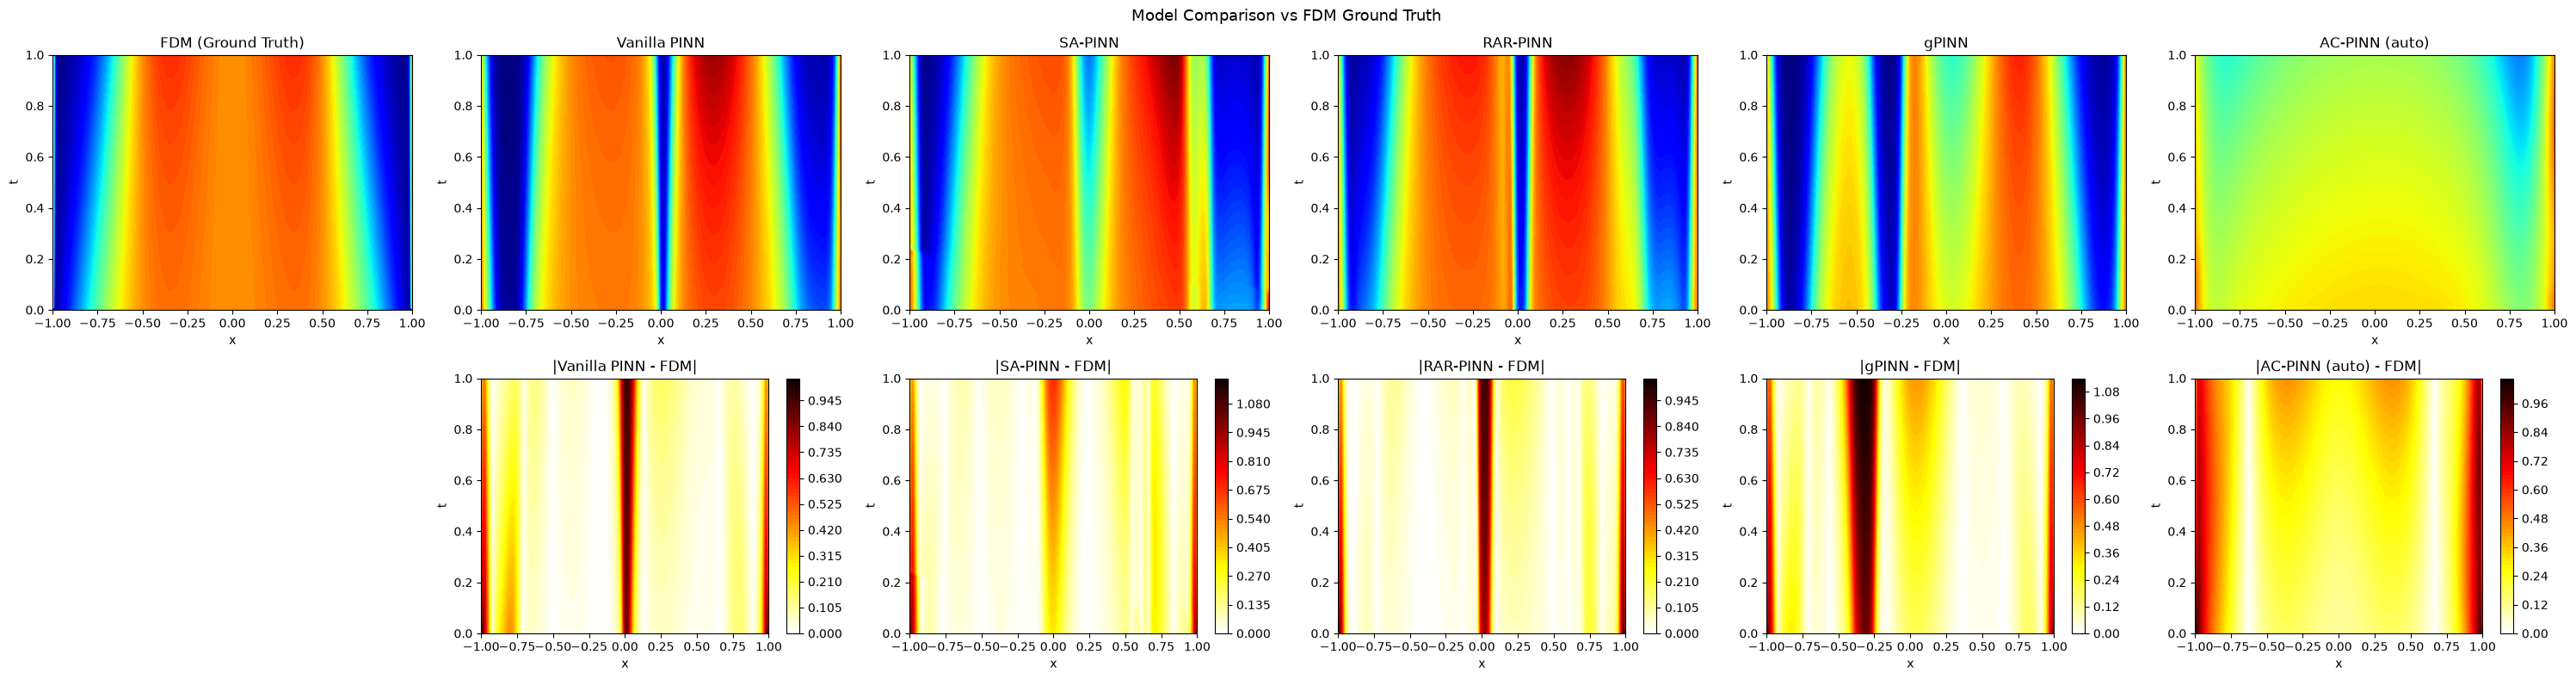

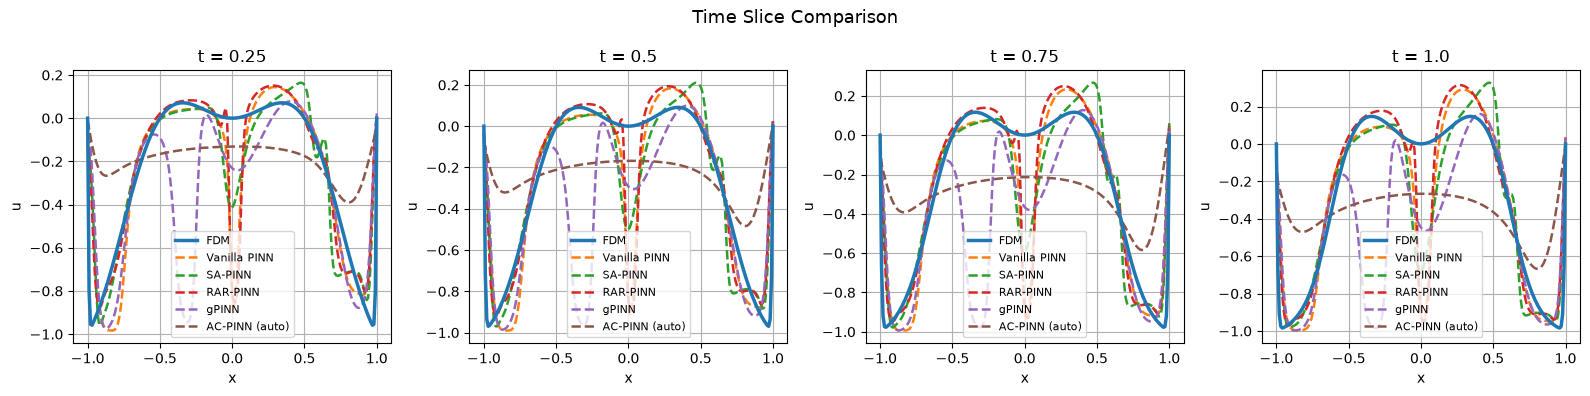

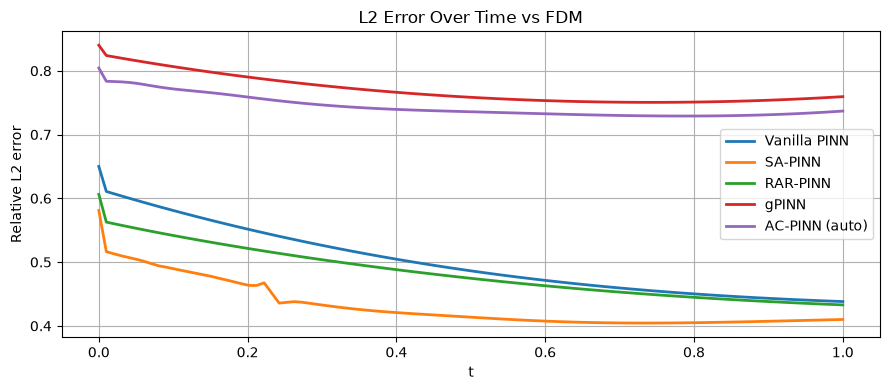



All 4 PDE baseline comparisons complete.


In [2]:
all_histories = {}   # pde -> {model_name: history}
all_metrics   = {}   # pde -> baseline_metrics dict (Rel L2/Max Err/MAE/RMSE per model)

for pde in PDES:
    cfg = PDE_CONFIGS[pde]
    print(f'\n{"#"*70}\n# PDE: {PDE_LABELS[pde]}\n{"#"*70}')

    results_dir = RESULTS + f'{pde}/'
    figures_dir = FIGURES + f'{pde}/'
    os.makedirs(results_dir, exist_ok=True)
    os.makedirs(figures_dir, exist_ok=True)

    gen_params = {k: v for k, v in cfg['pde_params'].items() if k in GEN_PARAMS}
    gen  = NoisyDataGenerator(pde=pde, **gen_params)
    data = gen.generate(**cfg['data_kwargs'])

    fdm = cfg['fdm_cls'](**cfg['fdm_kwargs'])
    fdm.solve()

    label_prefix = f'Baselines | {PDE_LABELS[pde]}'

    m1 = PINNSolver(pde=pde, layers=cfg['layers'], pde_params=cfg['pde_params'],
                     **cfg['vanilla_kwargs'])
    h1 = m1.fit(data, epochs=EPOCHS, print_every=2000, label=f'{label_prefix} | Vanilla')

    m2 = SAWeightPINN(pde=pde, layers=cfg['layers'], pde_params=cfg['pde_params'], weight_lr=1e-3)
    h2 = m2.fit(data, epochs=EPOCHS, print_every=2000, label=f'{label_prefix} | SA-PINN')

    m3 = RARPINNSolver(pde=pde, layers=cfg['layers'], pde_params=cfg['pde_params'],
                        rar_update_every=1000, rar_k=200,
                        rar_pool_size=10000, rar_max_points=6000)
    h3 = m3.fit(data, epochs=EPOCHS, print_every=2000, label=f'{label_prefix} | RAR-PINN')

    m4 = GPINNSolver(pde=pde, layers=cfg['layers'], pde_params=cfg['pde_params'], lambda_g=0.1)
    h4 = m4.fit(data, epochs=EPOCHS, print_every=2000, label=f'{label_prefix} | gPINN')

    m5 = ACPINNSolver(pde=pde, layers=cfg['layers'], pde_params=cfg['pde_params'],
                       N_pool=cfg['N_pool'], **ACPINN_INIT_KWARGS)
    h5 = m5.fit(data, epochs=EPOCHS, print_every=2000, label=f'{label_prefix} | AC-PINN (auto)',
                **ACPINN_FIT_KWARGS)

    models = [
        ('Vanilla PINN',    m1),
        ('SA-PINN',         m2),
        ('RAR-PINN',        m3),
        ('gPINN',           m4),
        ('AC-PINN (auto)',  m5),
    ]

    bench = Benchmark(fdm, nx=200, nt=100)
    for name, model in models:
        bench.add(name, model)
    bench.run()

    print(f'\n--- {PDE_LABELS[pde]} Baseline Benchmark Table (vs FDM ground truth) ---')
    metrics = bench.compare_metrics()
    save_metrics(metrics, results_dir + 'baselines_metrics.npy')

    for name, h in [('vanilla', h1), ('sapinn', h2), ('rarpinn', h3),
                     ('gpinn', h4), ('acpinn_auto', h5)]:
        save_history(h, results_dir + f'baselines_{name}.npy')

    all_histories[pde] = {
        'Vanilla': h1, 'SA-PINN': h2, 'RAR-PINN': h3, 'gPINN': h4, 'AC-PINN (auto)': h5,
    }
    all_metrics[pde] = metrics

    bench.plot_comparison(save_path=figures_dir + 'baselines_comparison.png')
    bench.plot_time_slices(save_path=figures_dir + 'baselines_time_slices.png')
    bench.plot_error_over_time(save_path=figures_dir + 'baselines_error_over_time.png')

print('\n\nAll 4 PDE baseline comparisons complete.')


## Combined Training Loss - All 4 PDEs

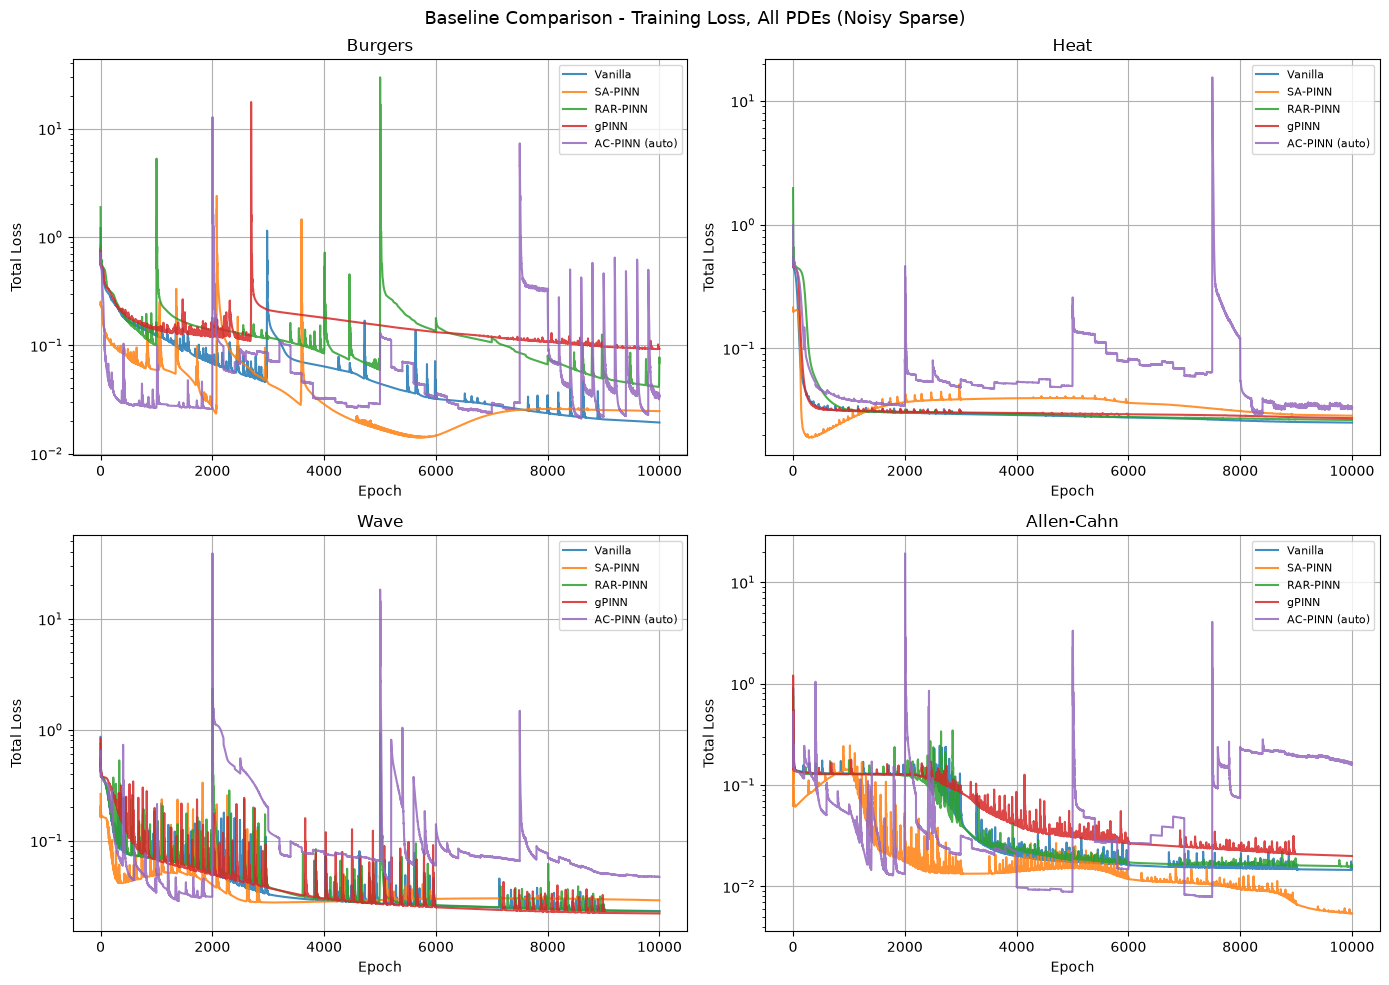

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, pde in zip(axes, PDES):
    for name, h in all_histories[pde].items():
        ax.plot(h['total'], label=name, alpha=0.85)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Total Loss')
    ax.set_title(PDE_LABELS[pde])
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('Baseline Comparison - Training Loss, All PDEs (Noisy Sparse)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES + 'comparison/baselines_training_loss_all_pdes.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary Table - All PDEs

Rel L2 error vs FDM ground truth for every model, on every PDE, under
the shared noisy-sparse condition.

In [4]:
print('=' * 95)
print(f"  {'PDE':<14} {'Model':<20} {'Rel L2':>10} {'Max Err':>10} {'MAE':>10} {'RMSE':>10}")
print('=' * 95)
for pde in PDES:
    for model_name, vals in all_metrics[pde].items():
        print(f"  {PDE_LABELS[pde]:<14} {model_name:<20} "
              f"{vals['l2']:>10.6f} {vals['max_error']:>10.6f} "
              f"{vals['mae']:>10.6f} {vals['rmse']:>10.6f}")
    print('-' * 95)
print('=' * 95)
print('\nBaseline comparison complete (all 4 PDEs).')


  PDE            Model                    Rel L2    Max Err        MAE       RMSE
  Burgers        Vanilla PINN           0.207694   1.167011   0.069494   0.126312
  Burgers        SA-PINN                0.757951   1.935262   0.169931   0.460959
  Burgers        RAR-PINN               0.570917   1.856032   0.140191   0.347211
  Burgers        gPINN                  0.427049   0.986864   0.141770   0.259716
  Burgers        AC-PINN (auto)         0.273241   0.843720   0.097014   0.166176
-----------------------------------------------------------------------------------------------
  Heat           Vanilla PINN           0.222775   0.523575   0.095454   0.149754
  Heat           SA-PINN                0.087502   0.157403   0.052029   0.058821
  Heat           RAR-PINN               0.146227   0.321790   0.069251   0.098297
  Heat           gPINN                  0.144131   0.316652   0.067746   0.096888
  Heat           AC-PINN (auto)         0.106412   0.161730   0.060087   0.071532
--